<a href="https://colab.research.google.com/github/Hem1144/AI-ML/blob/ml-labs/customer_segmentation_dataset_lab_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pyspark

In [3]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("CustomerSegmentation").getOrCreate()

In [4]:
spark

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
from pyspark.ml.feature import VectorAssembler, StringIndexer

# Load dataset
df = spark.read.csv("/content/drive/MyDrive/UEL/customer_segmentation_dataset.csv", header=True, inferSchema=True)

# Preprocessing
indexer = StringIndexer(inputCol="customer_segment", outputCol="label")
df_indexed = indexer.fit(df).transform(df)

# Assemble features
assembler = VectorAssembler(
    inputCols=["age", "annual_income", "spending_score", "years_as_customer", "number_of_purchases"],
    outputCol="features"
)
final_data = assembler.transform(df_indexed).select("features", "label")

# Split data
train_data, test_data = final_data.randomSplit([0.7, 0.3], seed=42)

Decision Tree Classifier

In [7]:
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

dt = DecisionTreeClassifier(labelCol="label", featuresCol="features")
dt_model = dt.fit(train_data)
dt_predictions = dt_model.transform(test_data)

# Evaluate accuracy
evaluator = MulticlassClassificationEvaluator(metricName="accuracy")
dt_accuracy = evaluator.evaluate(dt_predictions)
print(f"Decision Tree Accuracy: {dt_accuracy}")

Decision Tree Accuracy: 0.9898621228458276


 Logistic Regression with OneVsRest

In [8]:
from pyspark.ml.classification import LogisticRegression, OneVsRest

lr = LogisticRegression(maxIter=10)
ovr = OneVsRest(classifier=lr, labelCol="label")
ovr_model = ovr.fit(train_data)
ovr_predictions = ovr_model.transform(test_data)

# Evaluate accuracy
ovr_accuracy = evaluator.evaluate(ovr_predictions)
print(f"OneVsRest Logistic Regression Accuracy: {ovr_accuracy}")

OneVsRest Logistic Regression Accuracy: 0.9755580641514336


 Multinomial Logistic Regression

In [9]:
mlr = LogisticRegression(maxIter=10, family="multinomial")
mlr_model = mlr.fit(train_data)
mlr_predictions = mlr_model.transform(test_data)

# Evaluate accuracy
mlr_accuracy = evaluator.evaluate(mlr_predictions)
print(f"Multinomial Logistic Regression Accuracy: {mlr_accuracy}")

Multinomial Logistic Regression Accuracy: 0.9933803441951035


Confusion Matrix Visualization

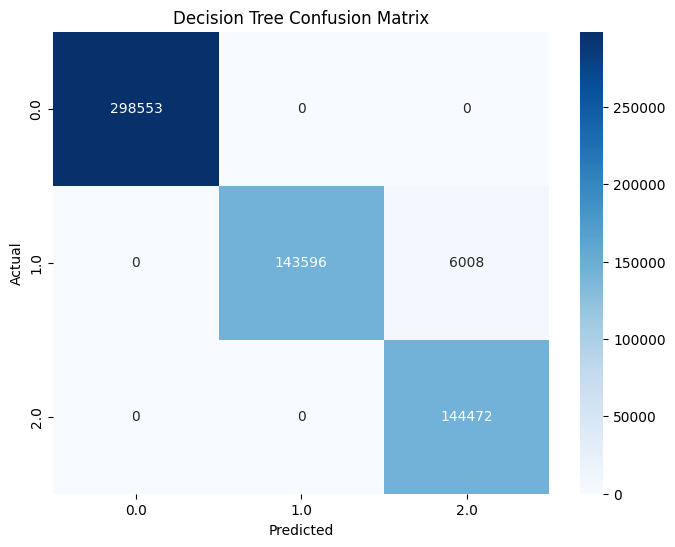

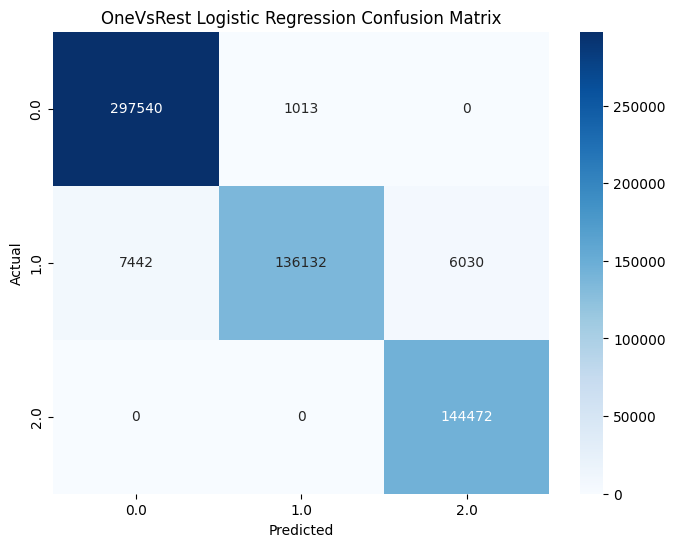

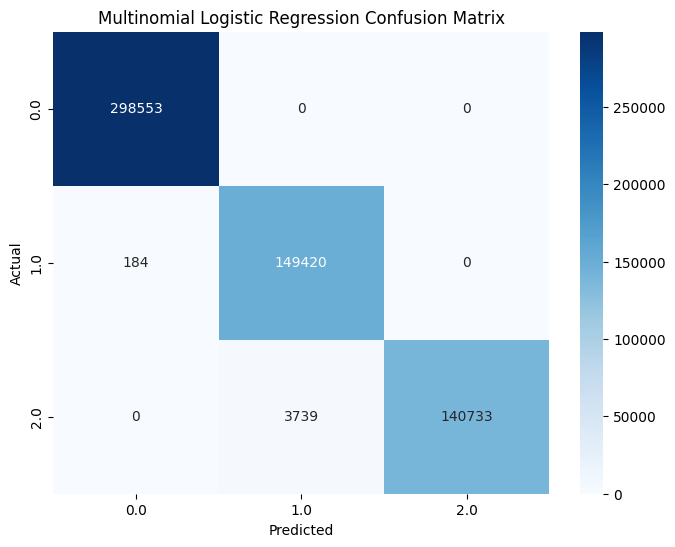

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_confusion_matrix(predictions, title):
    preds_df = predictions.select("label", "prediction").toPandas()
    cm = pd.crosstab(
        preds_df['label'],
        preds_df['prediction'],
        rownames=['Actual'],
        colnames=['Predicted']
    )
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.show()

# Generate confusion matrices
plot_confusion_matrix(dt_predictions, "Decision Tree Confusion Matrix")
plot_confusion_matrix(ovr_predictions, "OneVsRest Logistic Regression Confusion Matrix")
plot_confusion_matrix(mlr_predictions, "Multinomial Logistic Regression Confusion Matrix")